In [1]:
%matplotlib inline
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
# 1. Загрузка
image = cv2.imread('oh.jpg', cv2.IMREAD_GRAYSCALE)
print(image.shape, image.dtype)

(500, 1000) uint8


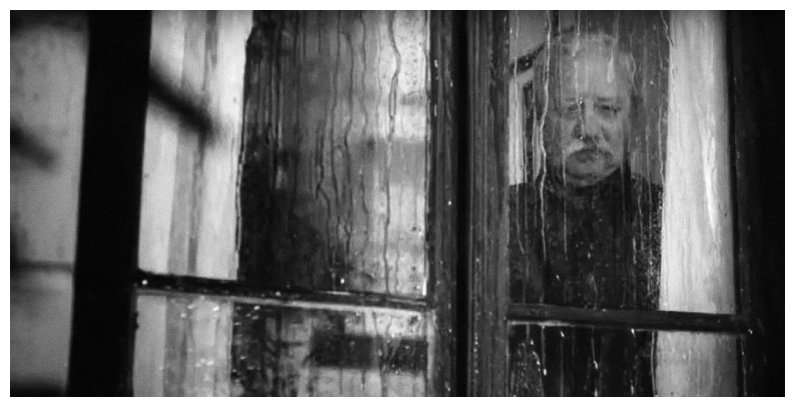

In [3]:
plt.figure(figsize=(10, 6))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [4]:
# 2. Гистограмма
histSize = 256
histRange = (0, 256)
accumulate = False

hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate=accumulate)

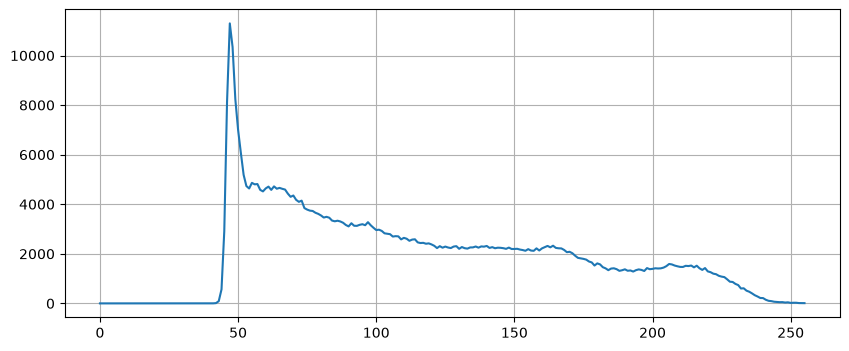

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(hist)
plt.grid(True)
plt.show()

In [6]:
# 3. Гамма-коррекция
def gamma_correction(img, gamma):
    #нормализация в диапазон [0, 1]
    normalized = img.astype(np.float32) / 255.0
    #возводение в степень gamma
    corrected = np.power(normalized, gamma)
    #возвращение обратно в диапазон [0, 255] и в uint8
    result = (corrected * 255).astype(np.uint8)
    return result

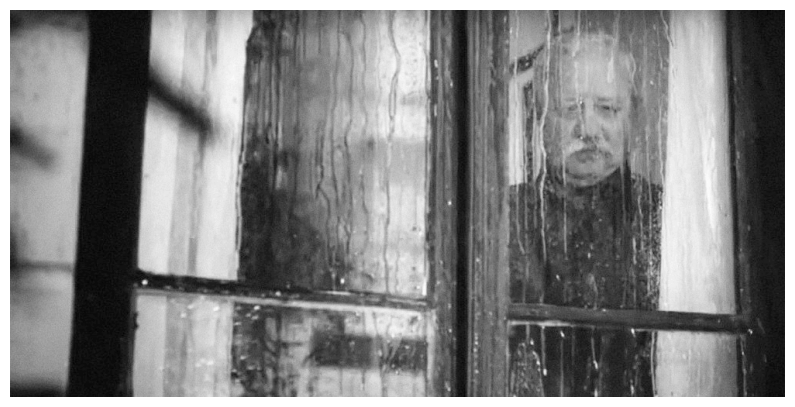

In [7]:
img_gamma_light = gamma_correction(image, 0.1)

plt.figure(figsize=(10, 6))
plt.imshow(img_gamma_light, cmap='gray')
plt.axis('off')
plt.show()

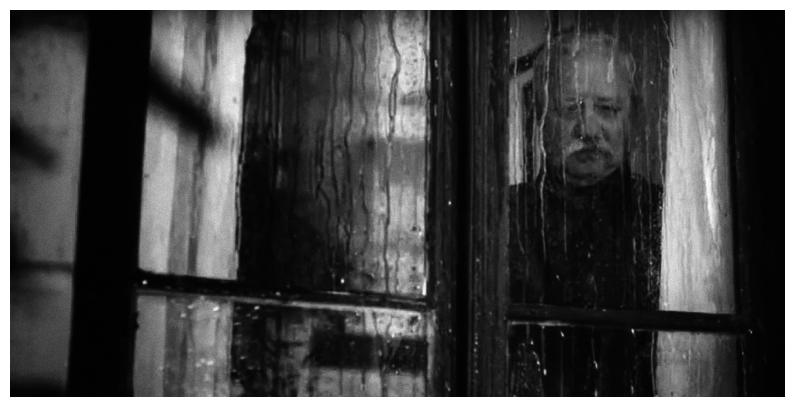

In [8]:
img_gamma_dark  = gamma_correction(image, 2.0)

plt.figure(figsize=(10, 6))
plt.imshow(img_gamma_dark, cmap='gray')
plt.axis('off')
plt.show()

In [9]:
# 4. MSE / SSIM
from skimage.metrics import structural_similarity, mean_squared_error

In [10]:
# SSIM
(ssim_light, diff_light) = structural_similarity(image, img_gamma_light, full=True)
(ssim_dark,  diff_dark)  = structural_similarity(image, img_gamma_dark,  full=True)
diff_light = (diff_light * 255).astype("uint8")
diff_dark  = (diff_dark  * 255).astype("uint8")

In [11]:
print(f"SSIM (исходное γ<1): {ssim_light:.4f}")
print(f"SSIM (исходное γ>1): {ssim_dark:.4f}")

SSIM (исходное γ<1): 0.5085
SSIM (исходное γ>1): 0.6631


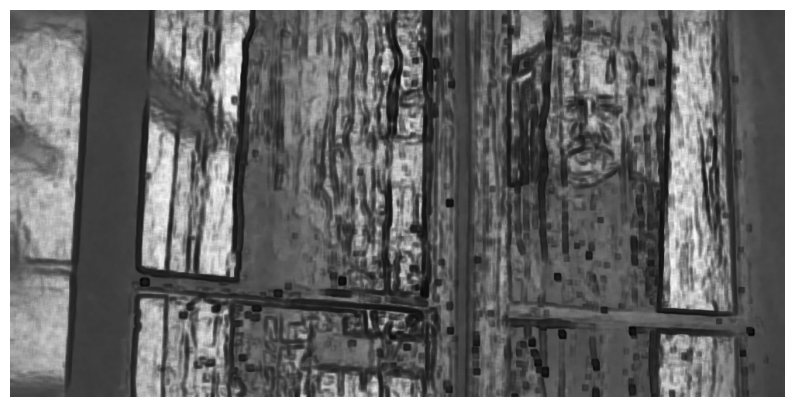

In [12]:
plt.figure(figsize=(10, 6))
plt.imshow(diff_light, cmap='gray')
plt.axis('off')
plt.show()

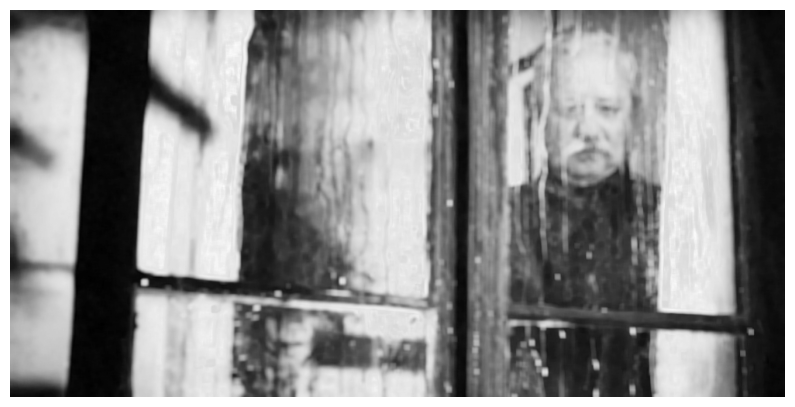

In [13]:
plt.figure(figsize=(10, 6))
plt.imshow(diff_dark, cmap='gray')
plt.axis('off')
plt.show()

In [14]:
# MSE
mse_light = mean_squared_error(image, img_gamma_light)
mse_dark  = mean_squared_error(image, img_gamma_dark)

In [15]:
print(f"MSE  (исходное γ<1): {mse_light:.4f}")
print(f"MSE  (исходное γ>1): {mse_dark:.4f}")

MSE  (исходное γ<1): 15910.9070
MSE  (исходное γ>1): 2835.8602


In [16]:
# 5. Статистическая коррекция
def stat_correction(img, mean_target, std_target):
    #приведение исходного к float для точности вычислений
    img_f = img.astype(np.float32)
    #статистика исходного
    mean_in = img_f.mean()
    std_in  = img_f.std()
    #непосредственно коррекция
    corrected = (img_f - mean_in) * (std_target / (std_in + 1e-8)) + mean_target
    #обрезание значений, вышедших за диапазон и возвращение к uint8
    return np.clip(corrected, 0, 255).astype(np.uint8)

In [17]:
eq_gray = cv2.equalizeHist(image)

mean_target = eq_gray.mean()
std_target  = eq_gray.std()

print("До коррекции:")
print(f"  mean = {image.mean():.2f}  (цель {mean_target:.2f})")
print(f"  std  = {image.std():.2f}   (цель {std_target:.2f})")

img_stat = stat_correction(image, mean_target, std_target)

print("После коррекции:")
print(f"  mean = {img_stat.mean():.2f}  (цель {mean_target:.2f})")
print(f"  std  = {img_stat.std():.2f}   (цель {std_target:.2f})")

До коррекции:
  mean = 113.51  (цель 128.41)
  std  = 53.43   (цель 73.14)
После коррекции:
  mean = 126.58  (цель 128.41)
  std  = 70.49   (цель 73.14)


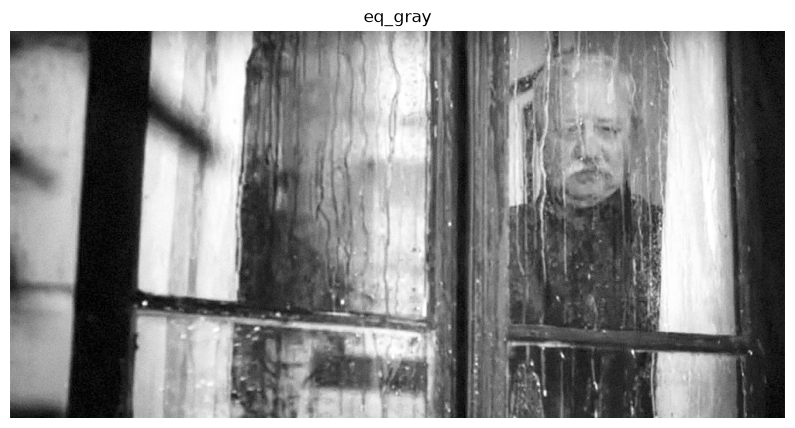

In [18]:
plt.figure(figsize=(10, 6))
plt.imshow(eq_gray, cmap='gray')
plt.title(f"eq_gray")
plt.axis('off')
plt.show()

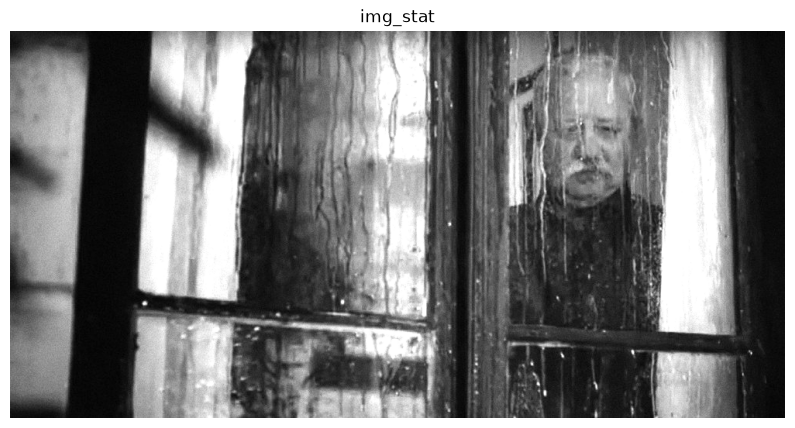

In [19]:
plt.figure(figsize=(10, 6))
plt.imshow(img_stat, cmap='gray')
plt.title(f"img_stat")
plt.axis('off')
plt.show()

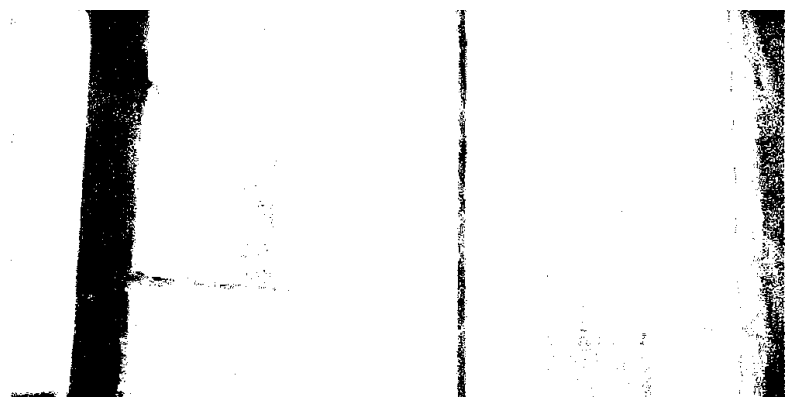

np.uint64(0)

In [20]:
# 6. Пороговая фильтрация

#порог 50, тип THRESH_BINARY
_,thresh50 = cv2.threshold(image,50,255,cv2.THRESH_BINARY)

plt.figure(figsize=(10, 6))
plt.imshow(thresh50, cmap='gray')
plt.axis('off')
plt.show()

thresh50[thresh50==100].sum()

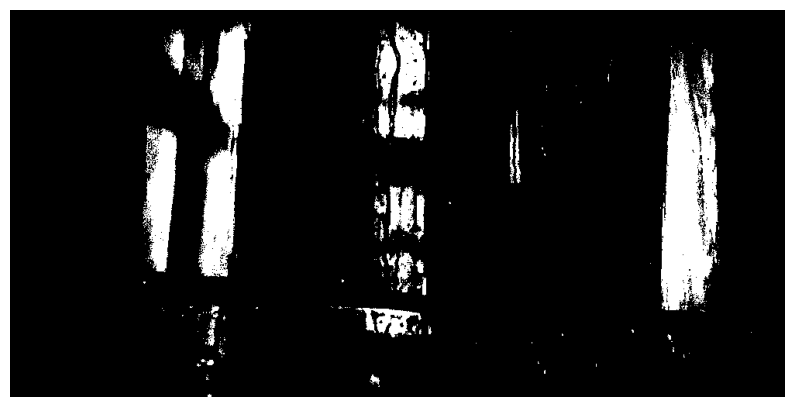

np.uint64(0)

In [21]:
#порог 200, тип THRESH_BINARY
_,thresh200 = cv2.threshold(image,200,255,cv2.THRESH_BINARY)

plt.figure(figsize=(10, 6))
plt.imshow(thresh200, cmap='gray')
plt.axis('off')
plt.show()

thresh200[thresh200==100].sum()

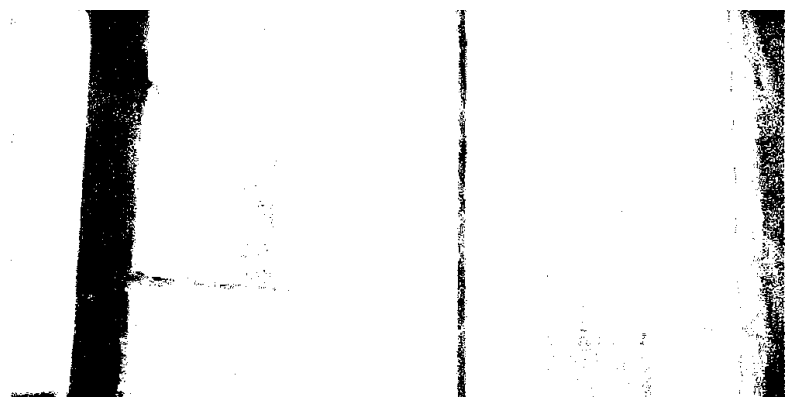

np.uint64(0)

In [22]:
#порог 50, тип THRESH_BINARY_INV
_,thresh_50 = cv2.threshold(image,50,255,cv2.THRESH_BINARY)

plt.figure(figsize=(10, 6))
plt.imshow(thresh_50, cmap='gray')
plt.axis('off')
plt.show()

thresh_50[thresh_50==100].sum()

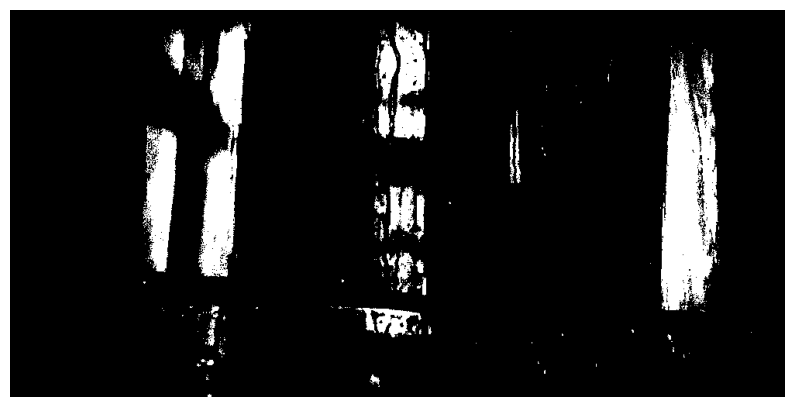

np.uint64(0)

In [23]:
#порог 200, тип THRESH_BINARY_INV
_,thresh_200 = cv2.threshold(image,200,255,cv2.THRESH_BINARY)

plt.figure(figsize=(10, 6))
plt.imshow(thresh_200, cmap='gray')
plt.axis('off')
plt.show()

thresh_200[thresh_200==100].sum()